In [1]:
from dotenv import load_dotenv
from IPython.display import display, Markdown

#### Define State

In [2]:
from langgraph.graph import MessagesState

In [3]:
class State(MessagesState):
    summary: str

#### Define Nodes

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, RemoveMessage
from langchain_core.output_parsers import StrOutputParser

In [5]:
chat = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite-preview",
    temperature = 0.6,
    max_output_tokens = 100,
    seed = 0
)

In [6]:
def ask_ques(state: State) -> State:    
    ai_msg = "Hi! How can I help you?"
    print("AI: ", ai_msg)

    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)], summary = state.get("summary", ""))    

In [7]:
def chatbot(state: State) -> State:
    print("Asking Chatbot...")

    sys_msg = f'''
    Here's a quick summary of the conversation so far:
    {state.get("summary", "")}

    Keep this in mind to answer the next question
    '''

    response = chat.invoke([SystemMessage(sys_msg)] + state["messages"])
    display(Markdown(StrOutputParser().invoke(response)))

    return State(messages = [response], summary = state.get("summary", ""))

In [8]:
def ask_more(state: State) -> State:
    ai_msg = "Would you like to ask another question? (yes/no)"
    print("AI: ", ai_msg)
    
    hum_msg = input(ai_msg)
    print("Human: ", hum_msg)

    return State(messages = [AIMessage(ai_msg), HumanMessage(hum_msg)], summary = state.get("summary", ""))

In [9]:
def summarize_message_history(state: State) -> State:
    print("Summarizing and deleting message history...")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content} \n\n"

    summary_instructions = f'''
    Give a summary of past conversation by incorporating context from the new conversation.
    
    Previous summary: {state.get("summary", "")}
    
    new_conversation: {new_conversation}
    '''

    new_summary = StrOutputParser().invoke(chat.invoke([HumanMessage(summary_instructions)]))
    display(Markdown(new_summary))

    removed_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]] # remove all messages

    return State(messages = removed_messages, summary = new_summary)

#### Define Routing Function

In [10]:
def routing_fn(state: State) -> str:
    if state["messages"][-1].content == "yes":
        return "yes"

    else:
        return "no"

#### Define Graph

In [11]:
from langgraph.graph import StateGraph

In [12]:
graph = StateGraph(State)

In [13]:
graph.add_node("Ask Question", ask_ques)
graph.add_node("ChatBot", chatbot)
graph.add_node("Ask More", ask_more)
graph.add_node("Summarize Message History", summarize_message_history)

graph.add_edge("__start__", "Ask Question")
graph.add_edge("Ask Question", "ChatBot")
graph.add_edge("ChatBot", "Ask More")
graph.add_edge("Summarize Message History", "Ask Question")

graph.add_conditional_edges(
    source = "Ask More",
    path = routing_fn,
    path_map = {"yes": "Summarize Message History", "no": "__end__"}
)

In [14]:
graph = graph.compile()

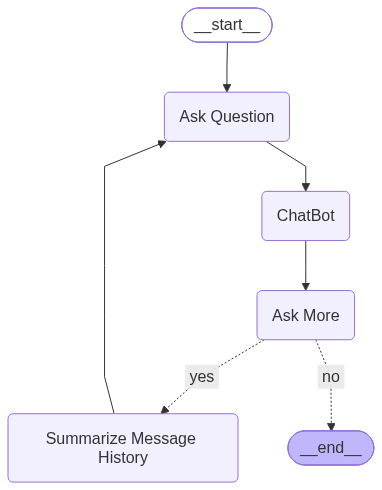

In [15]:
graph

#### Test the graph

In [16]:
graph.invoke(State(messages = [], summary = ""))

AI:  Hi! How can I help you?
Human:  Give a famous and short poem. Give the poem only.
Asking Chatbot...


The woods are lovely, dark and deep,   
But I have promises to keep,   
And miles to go before I sleep,   
And miles to go before I sleep.

AI:  Would you like to ask another question? (yes/no)
Human:  yes
Summarizing and deleting message history...


**Summary:**

The user requested a short, famous poem, and the AI provided the final stanza of Robert Frost's "Stopping by Woods on a Snowy Evening." Following the poem, the user expressed interest in continuing the conversation by answering "yes" to the AI's prompt for another question.

AI:  Hi! How can I help you?
Human:  Who is the author of this poem?
Asking Chatbot...


...

**Summary:**

The user is engaged in a conversation about the American poet Robert Frost. The interaction began with the user requesting a famous poem, leading the AI to provide the final stanza of "Stopping by Woods on a Snowy Evening." The user subsequently inquired about the author, the poem's publication date (1923), and most recently, the poet's birthplace and childhood (San Francisco, 1874). The user has indicated a desire to continue

AI:  Hi! How can I help you?
Human:  Do you remember my first question?
Asking Chatbot...


Yes, I do! Your very first question was to ask me for a famous poem by Robert Frost. 

In response, I provided the iconic final stanza of **"Stopping by Woods on a Snowy Evening."** 

Would you like to explore another one of his poems, or perhaps learn more about his life after he left San Francisco?

AI:  Would you like to ask another question? (yes/no)
Human:  no


{'messages': [AIMessage(content='Hi! How can I help you?', additional_kwargs={}, response_metadata={}, id='e32ffe7e-54e5-4209-a5d0-9a128dbd46a7', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Do you remember my first question?', additional_kwargs={}, response_metadata={}, id='6d328e0d-989b-448e-8012-a7cdbe7be03e'),
  AIMessage(content=[{'type': 'text', 'text': 'Yes, I do! Your very first question was to ask me for a famous poem by Robert Frost. \n\nIn response, I provided the iconic final stanza of **"Stopping by Woods on a Snowy Evening."** \n\nWould you like to explore another one of his poems, or perhaps learn more about his life after he left San Francisco?', 'extras': {'signature': 'EjQKMgERTTIPTl4BXlZEPFYMUnqNCKdali9kv8VuHIknJErwRX8t2K5UZtWoQ/pM4hsjChuW'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f73fc-493c-7121-a175-c530085ae2